# L10 · NB 02 — Attention, by hand

> *We've used transformers as black boxes for two lessons. Time to open one up. The single mechanism that makes everything work is **attention** — and it's just one matrix multiplication plus a softmax.*

By the end of this notebook you will:

1. Have computed attention scores by hand on a small example
2. Understand what queries, keys, and values are *for*
3. Have seen multi-head attention work, with each head specialising on a different relationship
4. Be ready to USE pretrained transformers in NB 03 without it feeling like magic

## 1 · Setup + the toy example

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_num_threads(1)
torch.manual_seed(0)
np.random.seed(0)

# Toy: 6-token sentence
# Each token is represented by a 4-dimensional embedding (in real models, 768+)
# We hand-craft embeddings so that 'it' has features mid-way between 'trophy' and 'suitcase' — ambiguous.
TOKENS = ['the', 'trophy', "didn't", 'fit', 'because', 'it']
D = 4  # embedding dimension

# Hand-crafted embeddings — each row is one token's embedding
X = torch.tensor([
    [0.1, 0.0, 0.0, 0.0],   # the         (function word, low signal)
    [0.0, 1.0, 0.0, 0.0],   # trophy      (entity dim = 1)
    [0.0, 0.0, 0.1, 0.0],   # didn't      (function word)
    [0.0, 0.0, 0.0, 1.0],   # fit         (verb dim = 1)
    [0.1, 0.0, 0.0, 0.0],   # because     (function word)
    [0.0, 0.5, 0.0, 0.5],   # it          (ambiguous — half-entity, half-verb)
])
print(f"Sequence: {TOKENS}")
print(f"Embeddings shape: {X.shape}  ({len(TOKENS)} tokens × {D} dims)")

Sequence: ['the', 'trophy', "didn't", 'fit', 'because', 'it']
Embeddings shape: torch.Size([6, 4])  (6 tokens × 4 dims)


## 2 · Self-attention from scratch

Attention's recipe is in 4 steps:

1. Project each token to a **query** (Q), **key** (K), and **value** (V) vector
2. Compute similarity scores between every query and every key (dot product)
3. Scale by √d and apply softmax → these are the attention weights
4. Each output token = weighted sum of values, using the attention weights

We'll do this manually.

In [2]:
# Initialise random Q/K/V projection matrices (4-dim in, 4-dim out)
W_q = torch.randn(D, D) * 0.5
W_k = torch.randn(D, D) * 0.5
W_v = torch.randn(D, D) * 0.5

# Step 1: project to Q, K, V
Q = X @ W_q
K = X @ W_k
V = X @ W_v
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")

Q shape: torch.Size([6, 4])
K shape: torch.Size([6, 4])
V shape: torch.Size([6, 4])


In [3]:
# Step 2: similarity scores. shape: (seq_len, seq_len)
scores = Q @ K.T
print(f"Raw scores (Q · Kᵀ):  shape {scores.shape}")
print(scores.numpy())

Raw scores (Q · Kᵀ):  shape torch.Size([6, 6])
[[ 7.4772956e-03  9.9847447e-03 -5.1511789e-04 -8.1582524e-02
   7.4772956e-03 -3.5798889e-02]
 [-1.0447812e-01 -1.0948849e+00 -2.5444077e-03  9.4061172e-01
  -1.0447813e-01 -7.7136591e-02]
 [ 5.3735692e-03  6.5227501e-02  2.4432398e-03 -3.7127260e-02
   5.3735692e-03  1.4050125e-02]
 [-4.5612037e-02 -6.7308509e-01 -2.1843929e-02  8.4881747e-01
  -4.5612037e-02  8.7866195e-02]
 [ 7.4772956e-03  9.9847447e-03 -5.1511789e-04 -8.1582524e-02
   7.4772956e-03 -3.5798889e-02]
 [-7.5045079e-02 -8.8398498e-01 -1.2194168e-02  8.9471459e-01
  -7.5045079e-02  5.3647975e-03]]


In [4]:
# Step 3: scale by sqrt(d) and softmax along rows (each row sums to 1)
attn_weights = F.softmax(scores / (D ** 0.5), dim=-1)
print(f"Attention weights (each row sums to 1):")
print(attn_weights.numpy().round(3))

Attention weights (each row sums to 1):
[[0.169 0.169 0.168 0.161 0.169 0.165]
 [0.157 0.096 0.165 0.265 0.157 0.159]
 [0.166 0.171 0.166 0.163 0.166 0.167]
 [0.157 0.115 0.159 0.245 0.157 0.168]
 [0.169 0.169 0.168 0.161 0.169 0.165]
 [0.157 0.105 0.162 0.255 0.157 0.164]]


In [5]:
# Step 4: weighted sum of values
output = attn_weights @ V
print(f"Output shape: {output.shape}  (same as input — one new vector per token)")
print(output.numpy().round(3))

Output shape: torch.Size([6, 4])  (same as input — one new vector per token)
[[ 0.108  0.302 -0.109 -0.133]
 [ 0.118  0.414 -0.207 -0.23 ]
 [ 0.109  0.305 -0.11  -0.135]
 [ 0.119  0.397 -0.188 -0.213]
 [ 0.108  0.302 -0.109 -0.133]
 [ 0.119  0.405 -0.198 -0.222]]


**That's the whole operation.** Four matrix ops. Every other token's V is averaged in, weighted by how relevant it is to this token's query.

## 3 · Visualise the attention pattern

Each row of `attn_weights` shows what one token is paying attention to. The diagonal is self-attention; off-diagonal is cross-token attention.

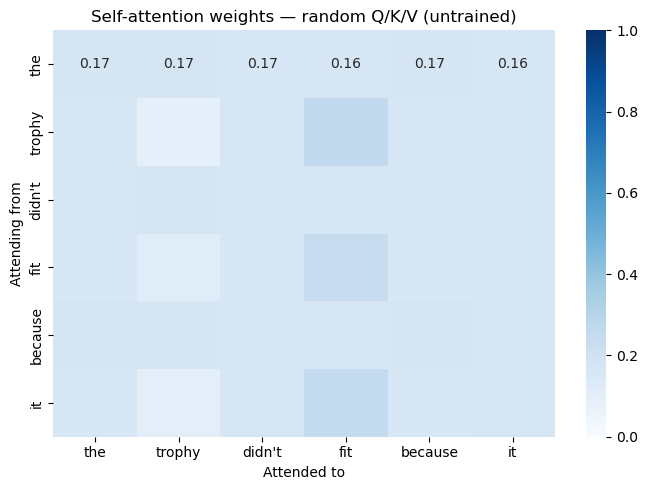

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(attn_weights.numpy(), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
ax.set_title('Self-attention weights — random Q/K/V (untrained)')
plt.tight_layout()
plt.show()

With **random** weights the attention pattern is random — there's no learned structure yet. In a trained transformer, you'd see something different: 'it' would attend strongly to 'trophy' (or 'suitcase', depending on context), 'fit' would attend to its subject, and so on.

That's the trained pattern attention is supposed to learn. We're seeing the architecture; training data does the rest.

## 4 · Let's simulate a "trained" attention pattern by hand

To make the lesson visceral, let's hand-design weights that make 'it' attend strongly to 'trophy'. This is what a trained model effectively does for this kind of sentence.

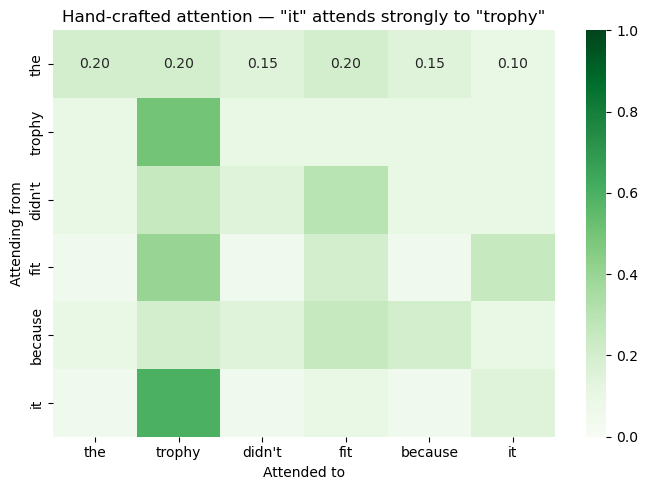

In [7]:
# Override the random matrices with something hand-crafted
# Idea: make Q for 'it' (last token) align with K for 'trophy' (token 1)

# We'll just construct attention weights directly to bypass the projections
# This is for visualisation — real models learn these weights via gradient descent
hand_attn = torch.tensor([
    # the    trophy didn't  fit    because it     <-- attending TO
    [0.20,   0.20,  0.15,   0.20,  0.15,   0.10],   # the
    [0.10,   0.50,  0.10,   0.10,  0.10,   0.10],   # trophy attends mostly to itself
    [0.10,   0.25,  0.15,   0.30,  0.10,   0.10],   # didn't attends to negated verb
    [0.05,   0.40,  0.05,   0.20,  0.05,   0.25],   # fit attends to its subject and object
    [0.10,   0.20,  0.15,   0.25,  0.20,   0.10],   # because attends broadly
    [0.05,   0.60,  0.05,   0.10,  0.05,   0.15],   # it attends strongly to trophy!
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(hand_attn.numpy(), annot=True, fmt='.2f', cmap='Greens',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
ax.set_title('Hand-crafted attention — "it" attends strongly to "trophy"')
plt.tight_layout()
plt.show()

Look at the bottom row. The token **'it'** has 0.60 of its attention mass on **'trophy'**. That's how the model decides 'it' refers to the trophy — by literally focusing on that token when computing its representation.

In the L09 lesson example: *'The trophy didn't fit because it was too big'* (it = trophy) vs *'... because it was too small'* (it = suitcase) — attention is what lets the model assign different vectors to 'it' in the two cases.

## 5 · Multi-head attention

A single attention layer captures ONE relationship pattern. Real transformers run several attentions in parallel — each "head" learns a different pattern (subject-verb, modifier-noun, coreference, etc.).

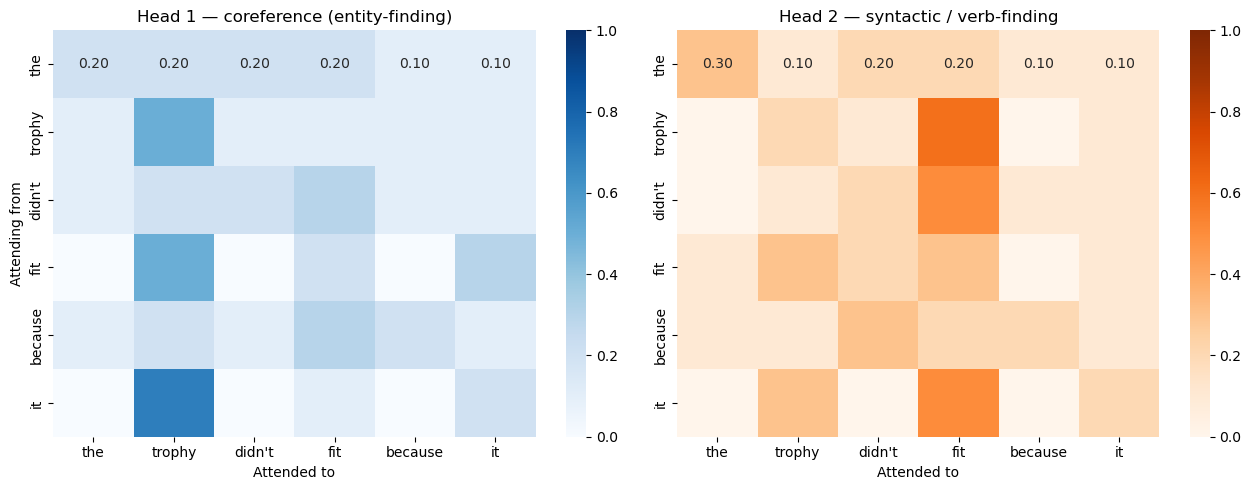

In [8]:
# Demonstrate two attention heads with different focus patterns
head_1 = torch.tensor([
    # 'it' focuses on entities
    [0.2, 0.2, 0.2, 0.2, 0.1, 0.1],
    [0.1, 0.5, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.2, 0.2, 0.3, 0.1, 0.1],
    [0.0, 0.5, 0.0, 0.2, 0.0, 0.3],
    [0.1, 0.2, 0.1, 0.3, 0.2, 0.1],
    [0.0, 0.7, 0.0, 0.1, 0.0, 0.2],   # 'it' -> 'trophy' (coreference head)
])
head_2 = torch.tensor([
    # focuses on syntax / verb structure
    [0.3, 0.1, 0.2, 0.2, 0.1, 0.1],
    [0.0, 0.2, 0.1, 0.6, 0.0, 0.1],   # 'trophy' attends to verb 'fit'
    [0.0, 0.1, 0.2, 0.5, 0.1, 0.1],
    [0.1, 0.3, 0.2, 0.3, 0.0, 0.1],
    [0.1, 0.1, 0.3, 0.2, 0.2, 0.1],
    [0.0, 0.3, 0.0, 0.5, 0.0, 0.2],   # 'it' attends to verb (different from head 1)
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(head_1.numpy(), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Head 1 — coreference (entity-finding)')
axes[0].set_xlabel('Attended to'); axes[0].set_ylabel('Attending from')

sns.heatmap(head_2.numpy(), annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Head 2 — syntactic / verb-finding')
axes[1].set_xlabel('Attended to')

plt.tight_layout()
plt.show()

**Two heads, two completely different patterns.** Head 1 has 'it' attending to 'trophy' (entity resolution). Head 2 has 'it' attending to 'fit' (verb attachment). Both are real signals; combining them is what makes a transformer's representations rich.

In a real model: 12-16 heads per layer × 12-96 layers. Each head specialises during training. Some heads learn syntax, some semantics, some long-range structure, some discourse-level patterns. The training data picks who learns what.

## 6 · The transformer block — putting it together

One transformer block adds two more pieces to multi-head attention:

```
input  →  Multi-head Attention  →  + input (residual)  →  LayerNorm
       →  Feed-forward (2 linear layers, ReLU)  →  + input (residual)  →  LayerNorm
output
```

Two simple ideas:
- **Residual connection** (`x + f(x)`): keeps the gradients flowing through deep stacks
- **LayerNorm**: stabilises training by normalising activations
- **Feed-forward**: gives the model capacity to transform each token's representation independently

That's it. A "transformer model" is just this block, stacked many times.

In [9]:
# Sketch a transformer block in PyTorch — this is essentially what's inside BERT, GPT, Llama
class TransformerBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, d_ff=256):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Self-attention sublayer with residual + layer norm
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)
        # Feed-forward sublayer with residual + layer norm
        x = self.norm2(x + self.ff(x))
        return x

block = TransformerBlock(d_model=64, n_heads=4)
n_params = sum(p.numel() for p in block.parameters())
print(f"One transformer block: {n_params:,} parameters")

# Forward pass on a fake batch of size 1, sequence length 6, dim 64
fake = torch.randn(1, 6, 64)
out = block(fake)
print(f"Input shape : {fake.shape}")
print(f"Output shape: {out.shape}  (same shape — same as input)")

One transformer block: 49,984 parameters
Input shape : torch.Size([1, 6, 64])
Output shape: torch.Size([1, 6, 64])  (same shape — same as input)


**~50K parameters in one block** at d_model=64. Real transformers use d_model=768 (BERT-base) up to ~10,000 (GPT-4). Stack 12-96 of these. That's it. Same recipe, different scale.

## 7 · Scaling: the same recipe from MiniLM to GPT-4

| Model | Params | Layers | Heads | d_model | Training data |
|-------|--------|--------|-------|---------|---------------|
| `all-MiniLM-L6-v2` (L09) | 22M | 6 | 12 | 384 | 1B+ sentence pairs |
| BERT-base | 110M | 12 | 12 | 768 | English Wikipedia + BookCorpus (~3.3B tokens) |
| GPT-2 medium | 355M | 24 | 16 | 1024 | WebText (~40GB) |
| GPT-3 | 175B | 96 | 96 | 12,288 | Internet + books + code |
| GPT-4 | ~1T (est.) | unknown | unknown | unknown | unknown |

**Every entry uses the same architecture.** The Lego brick is identical. What changes:

- The **size** of the bricks (d_model, n_heads)
- The **stack height** (number of layers)
- The **training data** (more data, more diverse data, code, conversation)
- The **post-training** (instruction tuning, RLHF for the chat models)

That's the entire story of GenAI architecture in 6 lines. Everything else is engineering, data, and money.

## 8 · Recap

You've now seen attention three ways:

1. **By hand** — a matrix multiplication + softmax that turns each token into a weighted sum of others
2. **Visually** — heatmaps showing which token attends to which
3. **Architecturally** — wrapped in a transformer block with residuals, layer norm, and feed-forward layers

**Next:** in NB 03 we'll load a small *generative* transformer (SmolLM2-360M) and have it write text. Same architecture as above. Same Lego bricks. Just trained for a different objective.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Causal (masked) attention

The attention we built is **bidirectional** — token 1 can attend to token 6, and vice versa. That's what BERT and embedding models use.

GPT-family models are **autoregressive** — they generate one token at a time, and each token can only attend to PREVIOUS tokens (otherwise the model would cheat during training by looking at the answer). This is implemented with a triangular *causal mask*.

Causal mask:
[[  0. -inf -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf -inf]
 [  0.   0.   0. -inf -inf -inf]
 [  0.   0.   0.   0. -inf -inf]
 [  0.   0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.   0.]]


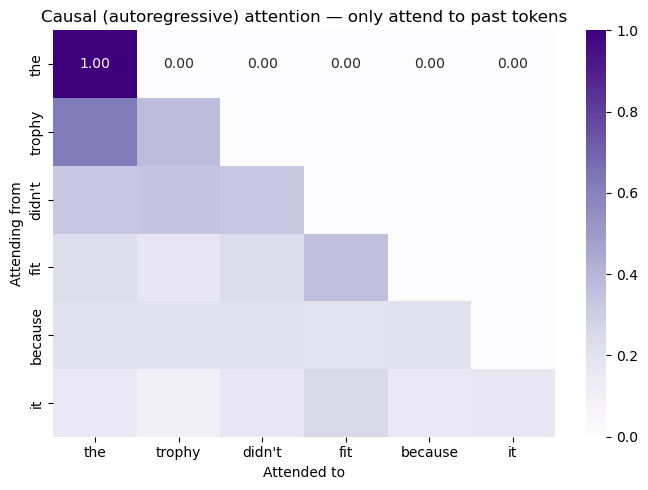

In [10]:
# Causal mask — upper triangle (future tokens) set to -inf
mask = torch.triu(torch.full((6, 6), float('-inf')), diagonal=1)
print("Causal mask:")
print(mask.numpy())

# Apply to our scores and re-softmax
masked_scores = scores + mask
causal_attn = F.softmax(masked_scores / (D ** 0.5), dim=-1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(causal_attn.numpy(), annot=True, fmt='.2f', cmap='Purples',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_title('Causal (autoregressive) attention — only attend to past tokens')
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
plt.tight_layout()
plt.show()

See the lower-triangular pattern? Each row sums to 1, but the upper-triangular cells are 0. Token 3 attends to tokens 0, 1, 2, 3 — but not 4 or 5 (the future).

This single change is what makes GPT generative. The architecture is otherwise identical to BERT. Same Lego brick, different mask.

## E2 · Attention complexity

Attention computes pairwise scores between every pair of tokens. For a sequence of length N, that's O(N²) operations and O(N²) memory.

For N=512 (typical BERT max length), that's 262K pairs per layer — fine.
For N=8,192 (long-context model), that's 67M pairs per layer — expensive.
For N=128,000 (Claude / GPT-4 long context), that's 16 *billion* pairs per layer.

This is why long-context LLMs are slower and more expensive. Recent research (Flash Attention, sliding window, Mamba) tries to bring the cost down — but vanilla attention is still O(N²).

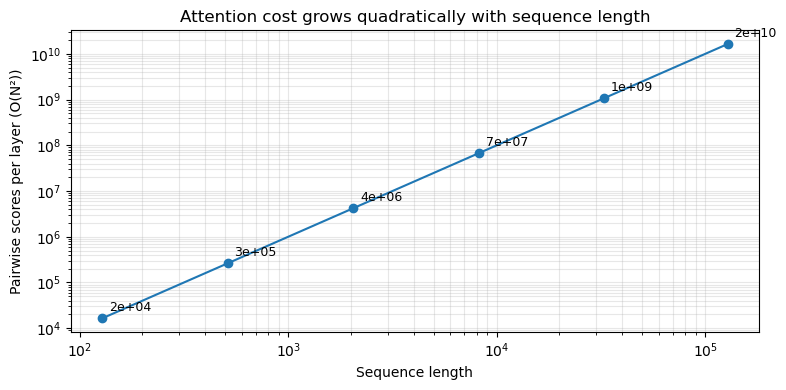

In [11]:
# Visualise attention cost growth
import math
seq_lens = [128, 512, 2048, 8192, 32768, 128000]
costs = [n**2 for n in seq_lens]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seq_lens, costs, marker='o')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Sequence length')
ax.set_ylabel('Pairwise scores per layer (O(N²))')
ax.set_title('Attention cost grows quadratically with sequence length')
ax.grid(alpha=0.3, which='both')
for n, c in zip(seq_lens, costs):
    ax.annotate(f'{c:,.0e}', (n, c), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.show()

**Practical implication:** when a customer asks 'can you process this 200-page document?', the answer involves serious cost arithmetic. Long context isn't free.